In [3]:
#  Import Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
# plt.rcParams['figure.figsize'] = (16,6)

#  Load Datasets
# -----------------------------
students = pd.read_csv('students.csv')
courses = pd.read_csv('courses.csv')
enrollments = pd.read_csv('enrollments.csv')

# Merge enrollment with students and courses
df = enrollments.merge(students, on='Student_ID', how='left')
df = df.merge(courses, on='Course_ID', how='left')

# print("Merged Dataset Shape:", df.shape)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15991 entries, 0 to 15990
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_ID    15991 non-null  object 
 1   Course_ID     15991 non-null  object 
 2   Grade         15991 non-null  object 
 3   Name          15991 non-null  object 
 4   Gender        15991 non-null  object 
 5   Age           15991 non-null  int64  
 6   Department_x  15991 non-null  object 
 7   Year          15991 non-null  int64  
 8   Attendance    15991 non-null  float64
 9   Study_Hours   15991 non-null  float64
 10  Current_GPA   15991 non-null  float64
 11  Course_Name   15991 non-null  object 
 12  Teacher_Name  15991 non-null  object 
 13  Department_y  15991 non-null  object 
 14  Credits       15991 non-null  int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 1.8+ MB


In [4]:
df.describe()

,Age,Year,Attendance,Study_Hours,Current_GPA,Credits
count,15991.000000,15991.000000,15991.000000,15991.000000,15991.000000,15991.000000
mean,21.513351,2.525733,74.869020,5.481871,2.998453,3.499343
std,2.295479,1.117465,14.532173,2.584911,0.575345,0.500015
min,18.000000,1.000000,50.030000,1.000000,2.000000,3.000000
25%,20.000000,2.000000,62.080000,3.300000,2.510000,3.000000
50%,21.000000,3.000000,74.610000,5.400000,3.000000,3.000000
75%,24.000000,4.000000,87.900000,7.700000,3.500000,4.000000
max,25.000000,4.000000,99.990000,10.000000,4.000000,4.000000


In [5]:
# Check Duplicate
df["Student_ID"].duplicated().sum()

np.int64(11991)

In [6]:
df.head()

,Student_ID,Course_ID,Grade,Name,Gender,Age,Department_x,Year,Attendance,Study_Hours,Current_GPA,Course_Name,Teacher_Name,Department_y,Credits
0,S0001,C010,D,Katherine Jackson,Female,19,Engineering,3,56.81,9.3,2.2,Electronics,Prof. Garcia,Engineering,3
1,S0001,C001,C,Katherine Jackson,Female,19,Engineering,3,56.81,9.3,2.2,Physics,Prof. Smith,Science,4
2,S0001,C008,B,Katherine Jackson,Female,19,Engineering,3,56.81,9.3,2.2,Engineering Math,Prof. Davis,Engineering,4
3,S0001,C004,A,Katherine Jackson,Female,19,Engineering,3,56.81,9.3,2.2,Economics,Prof. Khan,Commerce,3
4,S0001,C009,C,Katherine Jackson,Female,19,Engineering,3,56.81,9.3,2.2,Programming,Prof. Miller,Engineering,4


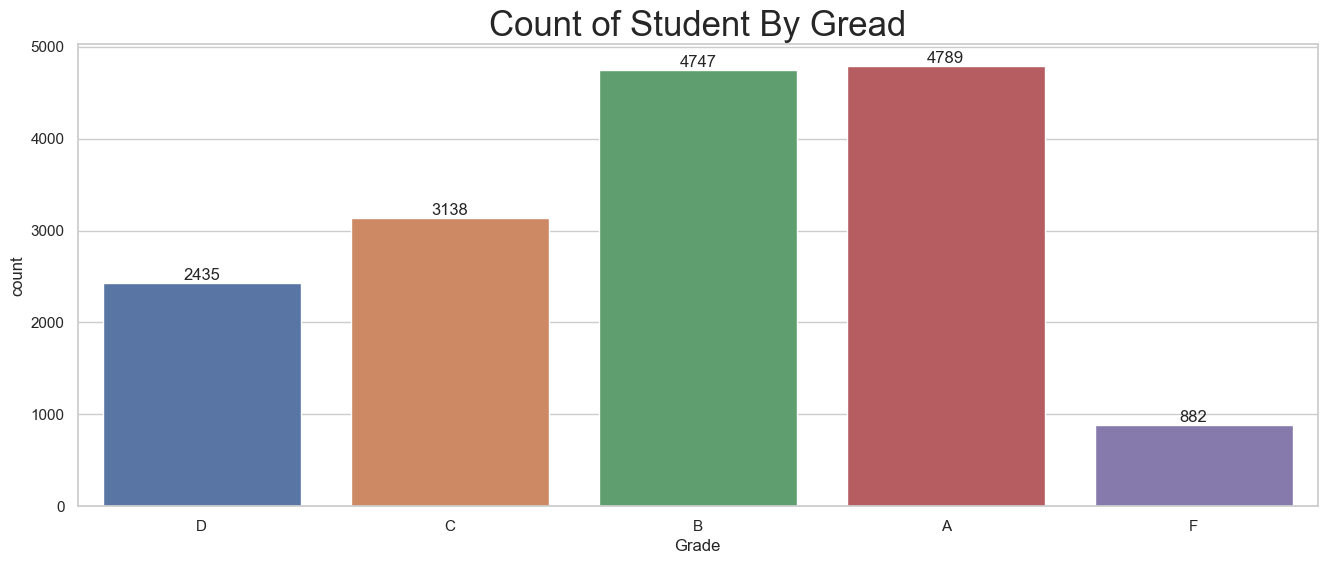

In [7]:
# count Gread 
plt.rcParams['figure.figsize'] = (16,6)
ax = sns.countplot(x = df['Grade'],data = df,hue='Grade')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Count of Student By Gread",fontsize = 25)
plt.show()


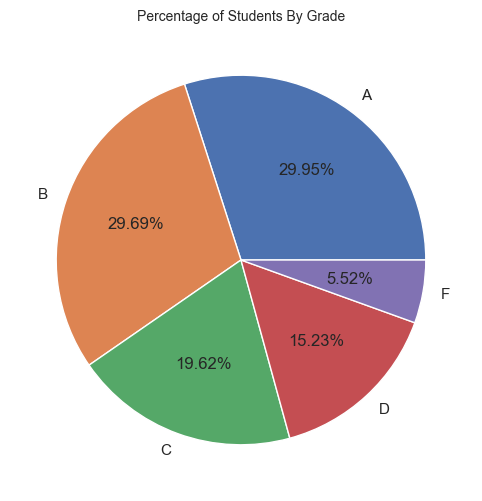

In [8]:
# Pie chart for Grade
gb = df.groupby(df["Grade"]).agg({'Grade' :"count"})
gb
plt.pie(gb['Grade'],labels = gb.index,autopct="%1.2f%%")
plt.title("Percentage of Students By Grade",fontsize = 10)
plt.show()

Form the Given pie chart We can Conclude that 29.95% of Our Students have Gread A, 29.69% Students have Gread B, 19.62% Students have Gread C, 15.23% Students have Gread D, 5.52% Students have Gread F

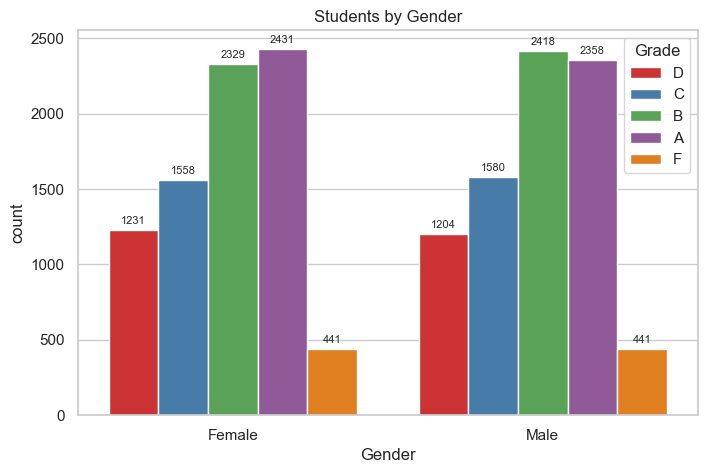

In [9]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x = df['Gender'],data = df,hue="Grade",palette="Set1")
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8, padding=3)
plt.title("Students by Gender")
plt.show()

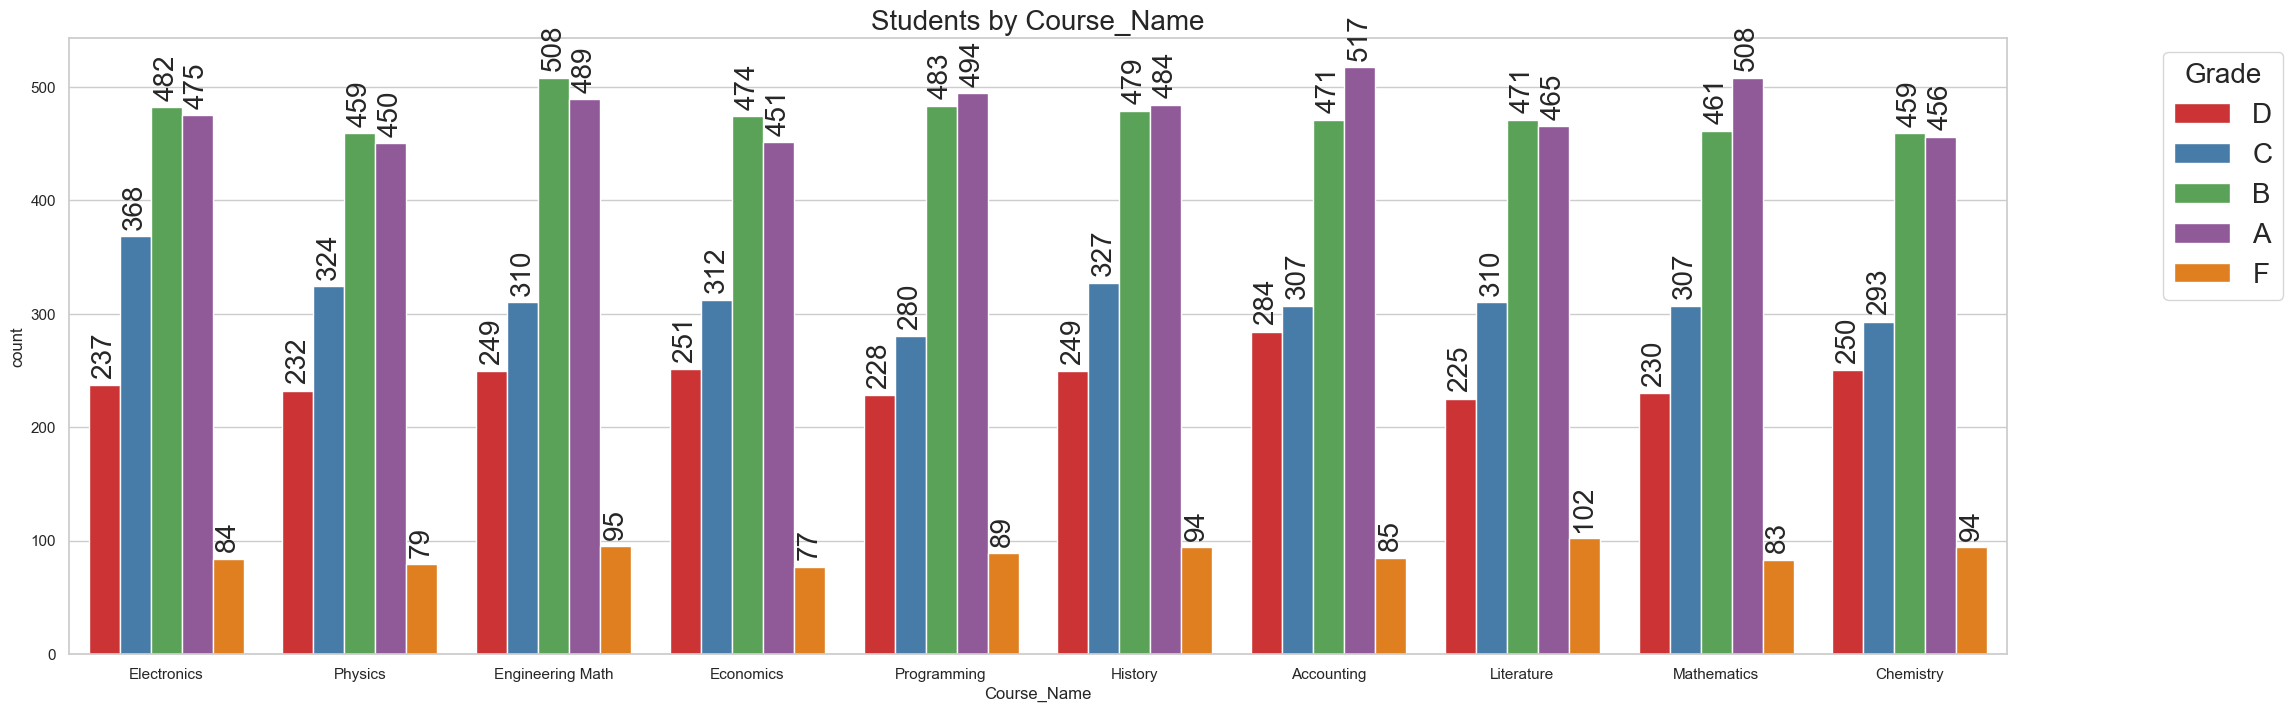

In [10]:
# Countplot for Course_Name
plt.figure(figsize=(25,8))
ax = sns.countplot(x = df['Course_Name'],data = df,hue="Grade",palette="Set1")
for bars in ax.containers:
    ax.bar_label(bars,fontsize=20,padding=5,rotation=90,)
plt.title("Students by Course_Name",fontsize = 20)
plt.legend(title="Grade",fontsize=20,title_fontsize=20,loc='upper right',bbox_to_anchor=(1.15, 1)) # Adjust legend position
plt.show()

From the Avobe Graph Count Students Grade By Course Name

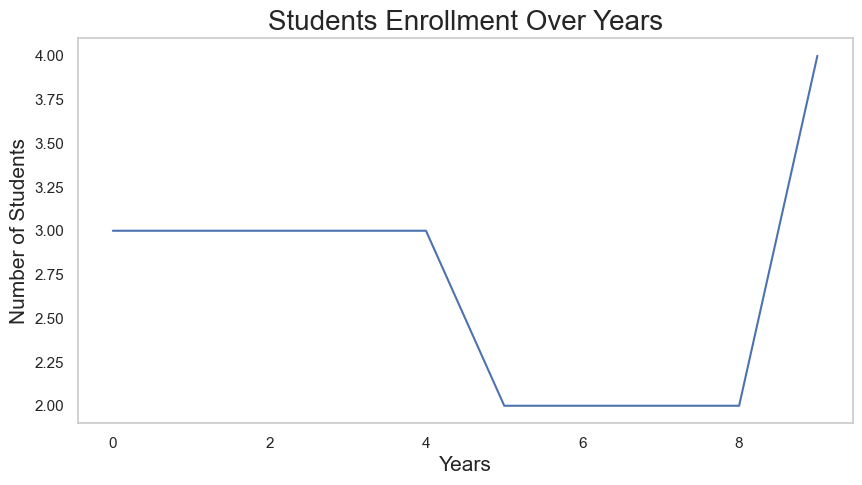

In [16]:
x = df['Year'].head(10)
plt.figure(figsize=(10,5))
plt.plot(x)
plt.title("Students Enrollment Over Years",fontsize = 20)
plt.xlabel("Years",fontsize = 15)
plt.ylabel("Number of Students",fontsize = 15)
plt.grid()
plt.show()

In [ ]:
df.columns.values

array(['Student_ID', 'Course_ID', 'Grade', 'Name', 'Gender', 'Age',
       'Department_x', 'Year', 'Attendance', 'Study_Hours', 'Current_GPA',
       'Course_Name', 'Teacher_Name', 'Department_y', 'Credits'],
      dtype=object)

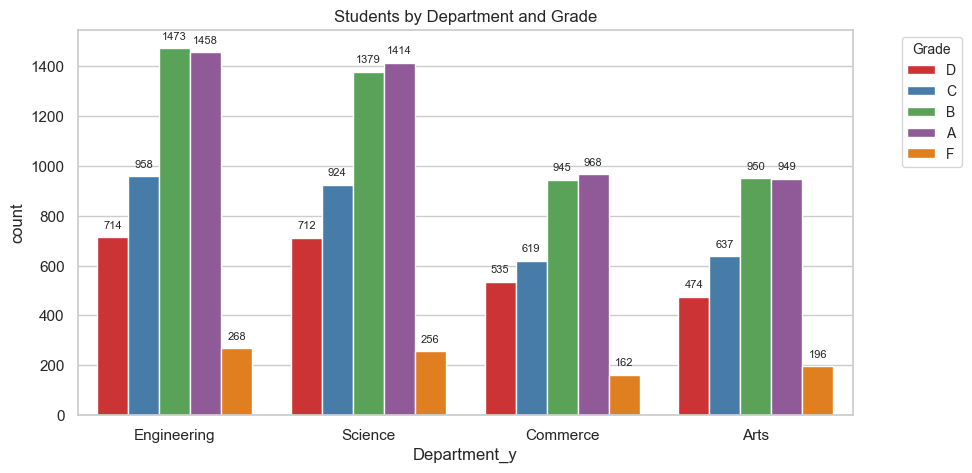

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x = df['Department_y'],data = df,hue="Grade",palette="Set1")
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8, padding=5)
plt.title("Students by Department and Grade")
plt.legend(title="Grade",fontsize=10,title_fontsize=10,loc='upper right',bbox_to_anchor=(1.15, 1)) # Adjust legend position
plt.show()


From The Avobe Graph Counting the students who can achive grades bY Department Subject

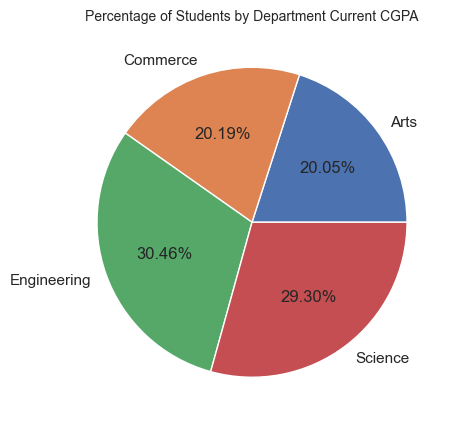

In [ ]:
# pie chart for Current_Cgpa and Department_x
plt.figure(figsize=(5,6))
gb = df.groupby(df["Current_GPA"]).agg({'Current_GPA' :"count"})
gb = df.groupby(df["Department_y"]).agg({'Current_GPA' :"count"})
gb
plt.pie(gb['Current_GPA'],labels = gb.index,autopct="%1.2f%%")
plt.title("Percentage of Students by Department Current CGPA",fontsize = 10)
plt.show()

Form the Avobe pie chart We can Conclude that 29.30% of Our Students have Cgpa in Science,30.46% Students have Cgpa in Engineering, 20.19% Students have Cgpa ib Commerce,20.05% students have Cgpa in Arts

C:\Users\pallab\AppData\Local\Temp\ipykernel_10248\3460026266.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="",fontsize=12,title_fontsize=15,loc='upper right',bbox_to_anchor=(1.15, 1)) # Adjust legend position


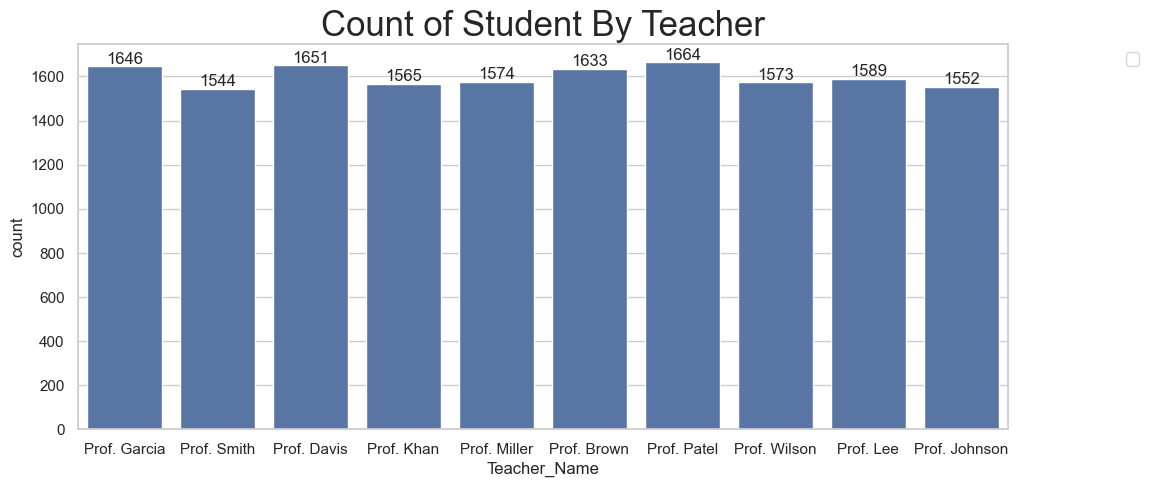

In [ ]:
plt.rcParams['figure.figsize'] = (12,5)
ax = sns.countplot(x = df['Teacher_Name'],data = df)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Count of Student By Teacher",fontsize = 25)
plt.legend(title="",fontsize=12,title_fontsize=15,loc='upper right',bbox_to_anchor=(1.15, 1)) # Adjust legend position
plt.show()

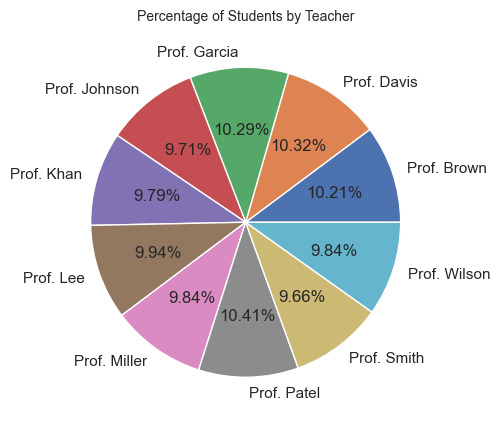

In [ ]:
# Pie chart for Teacher_Name
plt.figure(figsize=(5,6))
gb = df.groupby(df["Teacher_Name"]).agg({'Teacher_Name' :"count"})
gb
plt.pie(gb['Teacher_Name'],labels = gb.index,autopct="%1.2f%%")
plt.title("Percentage of Students by Teacher",fontsize = 10)
plt.show()